In [1]:
import google.auth
credentials, PROJECT_ID= google.auth.default()
print(credentials)
print(PROJECT_ID)

anbc-hcb-dev


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_komodo_Feb_2024_June_2023_embeddings` 
"""
kmdo = client.query(sql).to_dataframe() 
kmdo.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,0.439080,0.080255,-0.477010,-0.155486,0.195565,0.742208,-0.672388,-0.544305,0.137382,-0.392130,...,0.328378,-0.062854,-0.254263,-0.914905,0.830371,-0.355027,-0.040956,-0.063636,-0.841125,520108287
1,-0.439103,-0.073759,-0.510107,-0.345004,-0.076379,0.814164,-0.500342,-0.704165,0.575125,-0.102492,...,0.397844,-0.107834,-0.341100,-0.870074,0.667846,0.036254,0.322128,-0.567949,-0.157303,480514883
2,-0.445019,-0.279461,-0.722022,-0.134213,-0.077474,0.729250,-0.962365,-0.842522,0.630165,-0.477751,...,0.458297,0.217868,-0.486143,-1.024280,0.800492,0.390249,-0.100219,-0.965269,-0.080289,451266735
3,0.022217,0.434583,-0.707025,-0.555725,0.107678,-0.109800,-1.112773,-1.509479,0.042009,0.020355,...,-0.382142,0.396206,0.794209,-0.173562,1.147137,-0.493957,0.459321,-0.355242,0.432667,590049875
4,-0.008771,-0.441163,-0.222724,-0.246640,-0.598746,0.433860,-0.261189,-0.558725,0.387139,-0.098656,...,-0.033886,-0.242124,0.380713,-0.442306,1.019184,-0.390995,0.293174,-0.675926,-0.274718,480217146


In [4]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_member` 
"""
mem = client.query(sql).to_dataframe() 
mem.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group
0,480238914,48,VA,2023-06-01,DD,ABD
1,480266448,48,VA,2023-06-01,DD,ABD
2,480245725,48,VA,2023-06-01,DD,ABD
3,480374696,48,VA,2023-06-01,DD,ABD
4,480612042,48,VA,2023-06-01,DD,ABD


In [5]:
print(mem['coa_population_group'].value_counts())

TANF/CHIP    1566888
Expansion     731116
ABD           158875
BH            118451
LTSS           81785
Dual Elig      77420
Other          67490
Dual Int       46358
Name: coa_population_group, dtype: int64


In [6]:
mem = mem.rename(columns={"asdb_member_key": "individual_id"})

In [7]:
kmdo_mem = mem.merge(kmdo, on='individual_id', how='left')
kmdo_mem = kmdo_mem.assign(embed_type = 'komodo_integrated')
kmdo_mem.fillna(value = 0, inplace = True)

In [8]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcomes_revised` 
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.head()

,asdb_member_key,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,72786523,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
1,500297393,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
2,500366980,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
3,540051522,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
4,520366424,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0


In [9]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_mem.merge(outcomes, on='individual_id', how='left')

In [10]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcome_months` 
"""
outcome_tenure = client.query(sql).to_dataframe() 
outcome_tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,outcome_tenure
0,480273371,48,VA,2023-06-01,DD,ABD,6
1,480239344,48,VA,2023-06-01,DD,ABD,6
2,480284616,48,VA,2023-06-01,DD,ABD,6
3,480264959,48,VA,2023-06-01,DD,ABD,6
4,480238097,48,VA,2023-06-01,DD,ABD,6


In [11]:
outcome_tenure = outcome_tenure.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_outcome.merge(outcome_tenure, on='individual_id', how='left')

In [23]:
kmdo_outcome = kmdo_outcome.loc[kmdo_outcome['outcome_tenure'].isin([6,])]

In [24]:
kmdo_outcome.shape

(2274967, 286)

In [25]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_tenure` 
"""
tenure = client.query(sql).to_dataframe() 
tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
0,71941131,7,MCP,2023-06-01,DD,ABD,13
1,72811352,7,MCP,2023-06-01,DD,ABD,12
2,71744954,7,MCP,2023-06-01,DD,ABD,3
3,72780196,7,MCP,2023-06-01,DD,ABD,13
4,72803877,7,MCP,2023-06-01,DD,ABD,13


In [26]:
tenure = tenure.rename(columns={"asdb_member_key": "individual_id"})
tenure = tenure.set_index('individual_id')

In [27]:
pd.crosstab(tenure['tenure'], tenure['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [28]:
kmdo_outcome = kmdo_outcome.merge(tenure, on='individual_id', how='left')

In [29]:
kmdo_outcome.columns

Index(['asdb_plan_key_x', 'asdb_plan_nm_x', 'asdb_elig_dt_x',
       'coa_population_category_x', 'coa_population_group_x', 'emb0', 'emb1',
       'emb2', 'emb3', 'emb4',
       ...
       'asdb_elig_dt_x', 'coa_population_category_x', 'coa_population_group_x',
       'tenure_x', 'asdb_plan_key_y', 'asdb_plan_nm_y', 'asdb_elig_dt_y',
       'coa_population_category_y', 'coa_population_group_y', 'tenure_y'],
      dtype='object', length=292)

In [30]:
#kmdo_outcome.fillna(value = 0, inplace = True)
kmdo_outcome.head()

,asdb_plan_key_x,asdb_plan_nm_x,asdb_elig_dt_x,coa_population_category_x,coa_population_group_x,emb0,emb1,emb2,emb3,emb4,...,asdb_elig_dt_x,coa_population_category_x,coa_population_group_x,tenure_x,asdb_plan_key_y,asdb_plan_nm_y,asdb_elig_dt_y,coa_population_category_y,coa_population_group_y,tenure_y
individual_id,,,,,,,,,,,,,,,,,,,,,
480238914,48,VA,2023-06-01,DD,ABD,-0.448784,-0.357530,-0.219371,-0.724101,-0.211209,...,2023-06-01,DD,ABD,13,48,VA,2023-06-01,DD,ABD,13
480266448,48,VA,2023-06-01,DD,ABD,-0.015629,-0.849349,-0.263439,-0.060957,-0.191726,...,2023-06-01,DD,ABD,13,48,VA,2023-06-01,DD,ABD,13
480245725,48,VA,2023-06-01,DD,ABD,-0.071611,-1.195016,-0.404068,-0.210240,-0.550673,...,2023-06-01,DD,ABD,13,48,VA,2023-06-01,DD,ABD,13
480374696,48,VA,2023-06-01,DD,ABD,-0.450247,-0.554781,-0.588033,-0.370007,-0.452037,...,2023-06-01,DD,ABD,13,48,VA,2023-06-01,DD,ABD,13
480612042,48,VA,2023-06-01,DD,ABD,-0.201409,-0.406120,-0.611910,-0.224285,-0.384484,...,2023-06-01,DD,ABD,5,48,VA,2023-06-01,DD,ABD,5


In [31]:
print(kmdo_outcome['acute_ip_flag'].value_counts())

0    2236407
1      38560
Name: acute_ip_flag, dtype: Int64


In [32]:
kmdo_outcome = kmdo_outcome.set_index('individual_id')

KeyError: "None of ['individual_id'] are in the columns"

In [33]:
#split dataset in features and target variable
X = kmdo_outcome.iloc[:, 5:261] # Features
y = kmdo_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
individual_id,,,,,,,,,,,,,,,,,,,,,
480238914,-0.448784,-0.357530,-0.219371,-0.724101,-0.211209,0.323288,-0.240529,-0.370149,0.266635,-0.351347,...,-0.286912,0.102909,-0.230771,-0.523309,-0.512645,1.076144,-0.327042,0.703286,-0.690837,-0.567439
480266448,-0.015629,-0.849349,-0.263439,-0.060957,-0.191726,0.826683,-0.742410,-0.454017,0.268076,-0.366801,...,0.391520,0.073606,-0.016722,-0.562043,-0.869741,1.125594,-0.170607,0.024592,-0.467844,-0.467519
480245725,-0.071611,-1.195016,-0.404068,-0.210240,-0.550673,0.969296,0.023861,0.308874,0.620178,-0.483058,...,0.185392,0.205456,-0.227184,-0.807422,-1.367121,0.533995,0.190054,0.336111,-0.736591,-0.447941
480374696,-0.450247,-0.554781,-0.588033,-0.370007,-0.452037,0.543647,-0.190622,0.223016,0.462618,-0.336155,...,0.268604,0.010902,-0.093415,-0.210373,-0.667752,1.008607,-0.313662,0.179197,-0.360854,-0.393570
480612042,-0.201409,-0.406120,-0.611910,-0.224285,-0.384484,0.635537,-0.281614,-0.439862,0.249771,-0.048005,...,0.262506,0.068353,-0.068743,-0.399301,-0.352832,0.874620,-0.277950,0.036283,-0.636859,-0.037057


In [34]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [35]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [36]:
y_pred = logreg.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(568742, 1)

In [37]:
threshold = 0.3

y_predict_prob =logreg.predict_proba(X_test)[:, 1]
y_predict_lab = ((logreg.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,558033,1209
1,8737,763


In [38]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[558033,   1209],
       [  8737,    763]])

Text(0.5, 427.9555555555555, 'Predicted label')

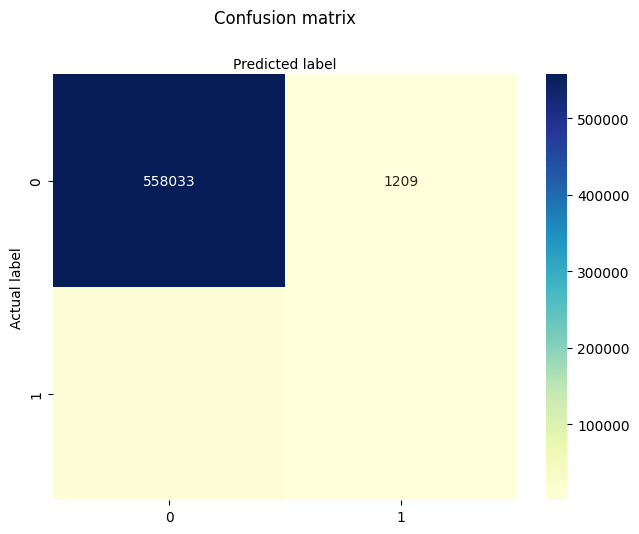

In [39]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [40]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.98      1.00      0.99    559242
     with IP       0.39      0.08      0.13      9500

    accuracy                           0.98    568742
   macro avg       0.69      0.54      0.56    568742
weighted avg       0.97      0.98      0.98    568742



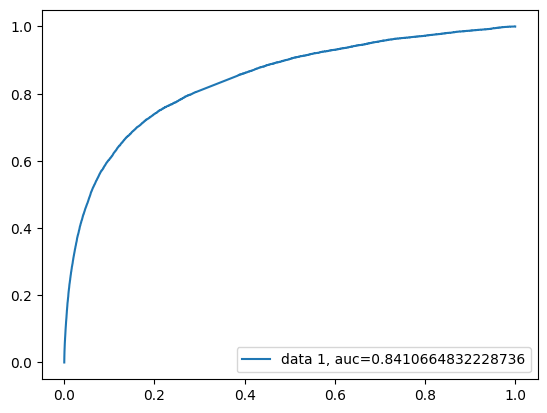

In [41]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

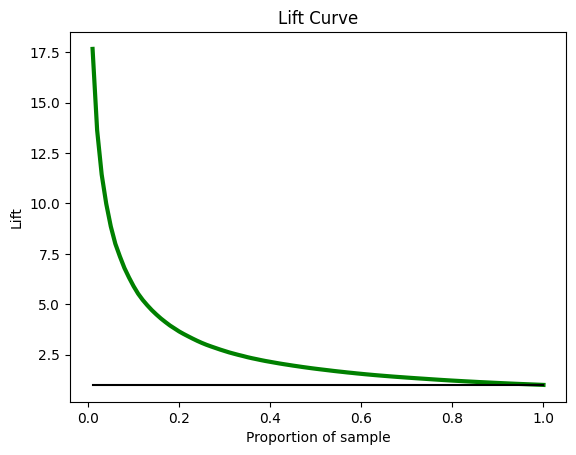

In [42]:
# Function that plots a Lift Curve using the real label values of a dataset and the probability predictions of a Machine Learning Algorithm/model
# @Params:
# y_val: real labels of the data
# y_pred: probability predictions for such data
# step: how big we want the steps in the percentiles to be

# imports
import numpy as np
import pandas as pd

def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_proba, step=0.01)

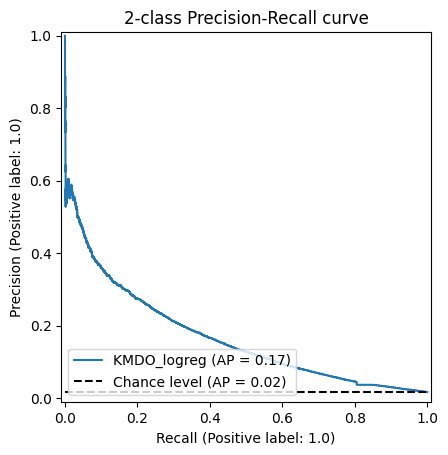

In [43]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    logreg, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [44]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [45]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.635944,0.197613,1678,5688,1.000102,17.663158,17.663158,1.000102,17.661357
1,0.197609,0.136328,912,5687,0.999926,9.6,27.263158,2.000028,13.631387
2,0.136318,0.105328,668,5688,1.000102,7.031579,34.294737,3.000130,11.431083
3,0.105325,0.085357,535,5687,0.999926,5.631579,39.926316,4.000056,9.981439
4,0.085344,0.071121,415,5688,1.000102,4.368421,44.294737,5.000158,8.858667
...,...,...,...,...,...,...,...,...,...
95,0.001511,0.001439,19,5688,1.000102,0.2,99.589474,95.999944,1.037391
96,0.001439,0.001359,13,5687,0.999926,0.136842,99.726316,96.999870,1.028108
97,0.001359,0.001262,15,5688,1.000102,0.157895,99.884211,97.999972,1.019227
98,0.001262,0.001126,7,5687,0.999926,0.073684,99.957895,98.999898,1.009677


In [46]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [47]:
df_out = pd.merge(y_pred, tenure, how = 'left',left_index = True, right_index = True)

In [48]:
df_out.shape
df_out.head()

,acute_ip_flag,y_predict_prob,y_predict_class,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,,,,
351932316,0,0.008157,0,35,IL,2023-06-01,TANF,TANF/CHIP,13
590213880,0,0.002993,0,59,KS,2023-06-01,CHIP,TANF/CHIP,6
351562145,0,0.000877,0,35,IL,2023-06-01,TANF,TANF/CHIP,13
352114091,0,0.009473,0,35,IL,2023-06-01,TANF,TANF/CHIP,2
440566352,0,0.015797,0,44,WV,2023-06-01,ABD Non Dual Non LTSS,ABD,13


In [49]:
print("% admitted post 6 months ABD: ", df_out[df_out['tenure'] <= 3]['acute_ip_flag'].mean()*100)
print("% admitted post 6 months BH: ", df_out[df_out['coa_population_group']=='BH']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Elig: ", df_out[df_out['coa_population_group']=='Dual Elig']['acute_ip_flag'].mean()*100)

% admitted post 6 months ABD:  1.8328901963002773
% admitted post 6 months BH:  2.3685393258426966
% admitted post 6 months Dual Elig:  5.173509597050972


In [62]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df    

In [63]:
lift_chart(df_out[df_out['tenure'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.516094,0.017259,239,3536,10.001697,36.882716,36.882716,10.001697,3.687646
1,0.017249,0.009473,59,3535,9.998869,9.104938,45.987654,20.000566,2.299318
2,0.009473,0.009473,55,3535,9.998869,8.487654,54.475309,29.999434,1.815878
3,0.009473,0.009473,52,3536,10.001697,8.024691,62.5,40.001131,1.562456
4,0.009473,0.009473,51,3535,9.998869,7.87037,70.37037,50.000000,1.407407
5,0.009473,0.009473,66,3535,9.998869,10.185185,80.555556,59.998869,1.342618
6,0.009473,0.009258,47,3536,10.001697,7.253086,87.808642,70.000566,1.254399
7,0.009253,0.005129,33,3535,9.998869,5.092593,92.901235,79.999434,1.161274
8,0.005128,0.002965,30,3535,9.998869,4.62963,97.530864,89.998303,1.083697
9,0.002965,0.000713,16,3536,10.001697,2.469136,100.0,100.000000,1.0


In [64]:
lift_chart(df_out[df_out['tenure'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.571773,0.022854,448,5586,10.001253,53.460621,53.460621,10.001253,5.345392
1,0.022851,0.011568,101,5585,9.999463,12.052506,65.513126,20.000716,3.275539
2,0.011567,0.009473,56,5585,9.999463,6.682578,72.195704,30.000179,2.406509
3,0.009473,0.009473,30,5585,9.999463,3.579952,75.775656,39.999642,1.894408
4,0.009473,0.007017,42,5586,10.001253,5.011933,80.787589,50.000895,1.615723
5,0.007017,0.004951,45,5585,9.999463,5.369928,86.157518,60.000358,1.43595
6,0.004951,0.003671,41,5585,9.999463,4.892601,91.050119,69.999821,1.300719
7,0.003671,0.002761,31,5585,9.999463,3.699284,94.749403,79.999284,1.184378
8,0.002761,0.002028,25,5585,9.999463,2.983294,97.732697,89.998747,1.085934
9,0.002027,0.000454,19,5586,10.001253,2.267303,100.0,100.000000,1.0


In [65]:
lift_chart(df_out[df_out['tenure'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.635944,0.040678,4935,47754,10.000105,61.579735,61.579735,10.000105,6.157909
1,0.040677,0.018032,1162,47753,9.999895,14.499626,76.079361,20.000000,3.803968
2,0.018031,0.010328,605,47754,10.000105,7.549289,83.62865,30.000105,2.787612
3,0.010328,0.007907,331,47753,9.999895,4.130272,87.758922,40.000000,2.193973
4,0.007907,0.005431,297,47754,10.000105,3.706014,91.464936,50.000105,1.829295
5,0.005431,0.003967,184,47753,9.999895,2.295982,93.760918,60.000000,1.562682
6,0.003967,0.003011,182,47753,9.999895,2.271026,96.031944,69.999895,1.371887
7,0.003011,0.002326,119,47754,10.000105,1.484901,97.516846,80.000000,1.218961
8,0.002326,0.001772,106,47753,9.999895,1.322685,98.839531,89.999895,1.098218
9,0.001772,0.000152,93,47754,10.000105,1.160469,100.0,100.000000,1.0


In [54]:
m0_3 = df_out.loc[df_out['tenure'].isin([0,1,2,3,])]
m4_8 = df_out.loc[df_out['tenure'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[df_out['tenure'].isin([9,10,11,12,13,])]

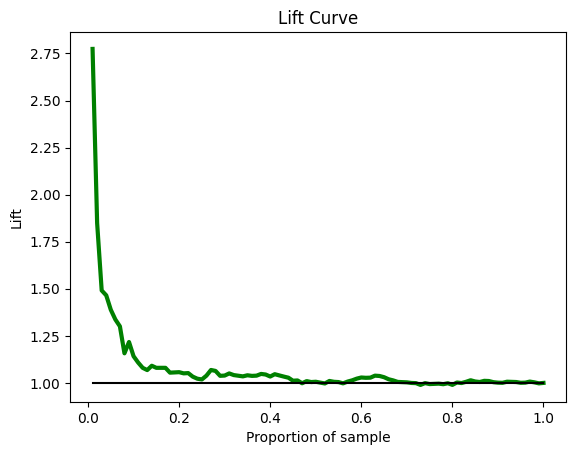

In [55]:
plot_lift_curve(m0_3['acute_ip_flag'], m0_3['y_predict_class'], step=0.01)

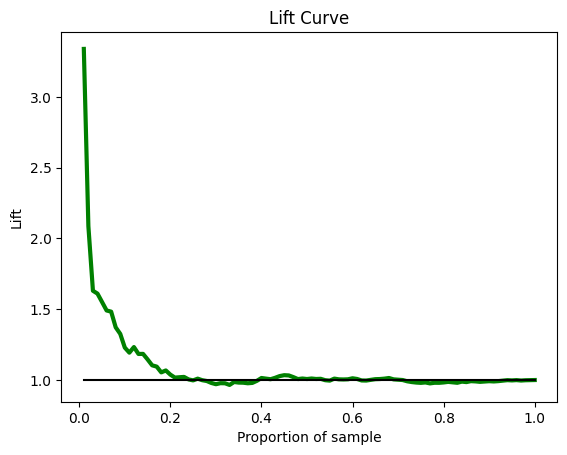

In [56]:
plot_lift_curve(m4_8['acute_ip_flag'], m4_8['y_predict_class'], step=0.01)

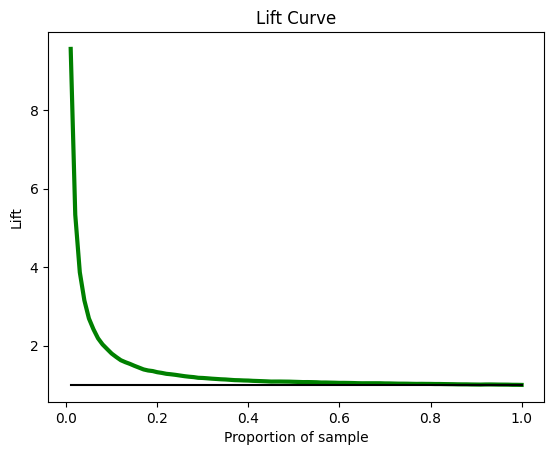

In [57]:
plot_lift_curve(m_9_13['acute_ip_flag'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
from joblib import dump, load
dump(logreg, 'Medicaid_IP_embeddings_only_logreg.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

In [ ]:
# create the data, or the data that is to be estimated
data = data.drop('TOTAL_DAYS_TO_COMPLETE', axis=1)

# Remove the order number since we don't need it
order_numbers = data['ORDER_NUMBER']
data = data.drop('ORDER_NUMBER', axis=1)

# # split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size = 0.2)

rf = RandomForestRegressor(
    bootstrap = True,
    max_depth = None,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 2,
    n_estimators  = 5000
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_differences = compare_values(y_test, rf_predictions)
rf_Avg = np.average(rf_differences)
print("#################################################")
print("DATA FOR RANDOM FORESTS")
print(rf_Avg)
importances = get_feature_importances(X_test.columns, rf.feature_importances_)
print()
print(importances)

res = y_test.to_frame('Actual Value')
res.insert(0, 'Predicted Value', rf_predictions)
res = order_numbers.to_frame().join(res, how='inner')
print(res)